::: {.thesis-hero-wrap}
<img src="images/survival-curves.svg" alt="Two step-function Kaplan-Meier survival curves for two groups, showing survival probability declining over time with a widening confidence band" class="thesis-hero-art"/>

::: {.thesis-hero-caption}
The shape every method in this tutorial is built to explain: a survival curve that steps down at each event, with uncertainty that widens as fewer people remain at risk.
:::
:::

::: {.tag-row}
[Kaplan-Meier]{.tag} [Cox Model]{.tag} [Survival Analysis]{.tag} [R]{.tag}
:::

## Introduction


Suppose a new cancer treatment is introduced, and researchers want to know whether it helps patients live longer. They recruit volunteers, follow them for several years, and record when each patient experiences an event such as disease recurrence or death.

At first glance, this might seem like a straightforward prediction problem. Why not simply calculate the average survival time or fit a standard regression model?

The challenge is that real-world studies are not so straightforward. Some patients leave the study early, some are still alive when the study ends, and others are lost to follow-up. For these individuals, we know that the event has **not yet occurred**, but we do not know exactly **when** it eventually will. Ignoring these partially observed cases discards valuable information, while treating them as complete observations leads to biased conclusions.

**Survival analysis** helps  to solve this problem.

Survival analysis is designed to analyze **time-to-event data**—that is, data in which the outcome of interest is not simply *whether* an event occurs, but **when** it occurs. Although the name originated in medical research, where the event was often death or disease recurrence, the methodology applies to various situations involving the timing of an event.

Example cases:

* How long do cancer patients survive after treatment?
* When does a patient experience disease relapse?
* How long until a machine fails in a manufacturing plant?
* When does a customer cancel a subscription service?
* How long before a software system crashes?
* When does a genetic mutation become fixed in a population?

What makes these problems unique is that the timing of the event carries just as much information as the event itself.

A defining feature of survival data is **censoring**. Not every participant experiences the event during the observation period. For example, if a clinical trial ends after five years and a patient is still alive, we only know that their survival time is **at least five years**—their true survival time remains unknown. Classical statistical methods such as linear regression are not designed to handle these incomplete observations appropriately, whereas survival analysis incorporates them naturally, allowing researchers to use all available information without introducing systematic bias.

Over the past several decades, survival analysis has become one of the most important statistical tools in medicine, epidemiology, public health, engineering, economics, reliability analysis, and increasingly in data science and machine learning. Whether evaluating new therapies, estimating equipment reliability, modeling customer retention, or studying disease progression, the central question remains the same:

> **Given what we know today, how does the probability of experiencing an event change over time?**

In this tutorial, we will build an intuitive understanding of the two foundational methods in survival analysis:

* **Kaplan–Meier estimation**, which estimates the probability of surviving over time without assuming a specific statistical model.
* **The Cox proportional hazards model**, which quantifies how predictors such as age, treatment, or genetic factors influence the instantaneous risk of experiencing the event.

We will try understand the statistical ideas and the underlying mathematics behind them , and implement each technique in **R** using some simple examples.



## Basic Survival Quantities

Before learning the Kaplan–Meier estimator or the Cox proportional hazards model, it is important to understand the three mathematical quantities that form the foundation of survival analysis.

Suppose we follow an individual from the start of a study until an event occurs—for example, death, disease relapse, machine failure, or customer churn. The time until this event is called the **survival time** or **event time**.

We denote this event time by the random variable $T$.

Because different individuals experience the event at different times, we treat $T$ as a **random variable**, meaning that its exact value is uncertain before we observe it.

Survival analysis is built around three closely related functions:

* **The survival function**, which tells us the probability that an individual remains event-free beyond a given time.
* **The hazard function**, which measures the instantaneous risk of experiencing the event at a particular moment, assuming the individual has survived up to that time.
* **The cumulative hazard function**, which accumulates this risk over time.

Together, these three quantities describe the same underlying process from different perspectives.

### 1. Survival Function

The most intuitive quantity is the **survival function**.

It answers the question:

> **What is the probability that an individual survives beyond time $t$?**

Mathematically,

$$
S(t)=P(T>t)=1-F(t),
$$

where

* $T$ is the event time,
* $F(t)$ is the cumulative distribution function (CDF), representing the probability that the event has already occurred by time $t$.

As time increases, the survival probability can only stay the same or decrease.

---

### 2. Hazard Function

While the survival function describes the probability of remaining event-free, researchers are often interested in something slightly different:

> **Among individuals who have survived until time $t$, how likely is the event to occur immediately afterward?**

This idea is captured by the **hazard function**, sometimes called the **instantaneous event rate** or **instantaneous risk**.

It is defined as

$$
h(t)=\lim_{\Delta t\rightarrow0}
\frac{P(t\le T<t+\Delta t\mid T\ge t)}
{\Delta t}.
$$

Notice the conditioning.

The hazard is **not** the probability of dying at time $t$. Instead, it measures the instantaneous rate at which events occur among those who are still at risk just before time $t$.

This distinction is one of the most important concepts in survival analysis.

---

### 3. Relationship Between Hazard and Survival

Although the survival and hazard functions describe different ideas, they contain exactly the same information.

Starting from the definition of conditional probability,

$$
h(t)=\frac{f(t)}{S(t)},
$$

where

* $f(t)$ is the probability density function (PDF),
* $S(t)$ is the survival function.

Since

$$
f(t)=-\frac{dS(t)}{dt},
$$

we obtain

$$
h(t)
=-\frac{d}{dt}\log S(t).
$$

This equation tells us that the hazard is simply the rate at which the logarithm of the survival probability decreases over time.

---

### 4. Cumulative Hazard Function

Rather than looking only at the instantaneous hazard, it is often useful to consider the **total accumulated hazard** up to time $t$.

This is called the **cumulative hazard function**:

$$
H(t)
=\int_0^t h(u),du.
$$

Integrating the previous relationship gives

$$
H(t)
=-\log S(t),
$$

or equivalently,

$$
S(t)=\exp[-H(t)].
$$

This elegant identity shows that the survival function and cumulative hazard function are simply two different mathematical representations of the same underlying phenomenon.

---

### Why These Quantities Matter

These definitions are more than mathematical formalities—they motivate the two most widely used methods in survival analysis.

* **Kaplan–Meier estimation** focuses on estimating the survival function $S(t)$ directly from observed data.
* **The Cox proportional hazards model** focuses on modeling the hazard function $h(t)$ and how it changes with patient characteristics such as age, treatment, or genetic factors.

Although the two methods approach the problem from different directions, they are linked through the relationship

$$
S(t)=\exp[-H(t)].
$$

Understanding this connection makes it much easier to see how the Kaplan–Meier estimator and the Cox model fit together within a single statistical framework.







## The Kaplan–Meier Estimator

The **Kaplan–Meier estimator** is the most widely used non-parametric method for estimating the survival function from observed data.

Its goal is straightforward:

> **Given a group of individuals, what is the probability of remaining event-free over time?**

Unlike parametric survival models, the Kaplan–Meier estimator makes **no assumptions** about the underlying distribution of survival times. Instead, it estimates the survival curve directly from the observed data while naturally accounting for censored observations.

### The Data We Observe

In an ideal study, we would know the exact event time for every individual. In practice, however, this is rarely possible. Some participants experience the event during follow-up, while others are still event-free when the study ends or are lost to follow-up. For these individuals, we only know that the event occurs **after** their last observed time.

To accommodate this, survival analysis records two pieces of information for each individual:

1. **The observed follow-up time**
2. **Whether the event occurred during follow-up**

Mathematically, for the $i$-th individual, we observe

$$
Y_i=\min(T_i,C_i),
$$

where

* $T_i$ is the true event time,
* $C_i$ is the censoring time,
* $Y_i$ is the observed follow-up time, equal to whichever occurs first.

We also define an **event indicator**

$$
\delta_i=
\begin{cases}
1, & \text{if the event occurred},\
0, & \text{if the observation was censored}.
\end{cases}
$$

Thus, each observation consists of the pair $(Y_i,\delta_i)$.

---

### Constructing the Risk Set

The Kaplan–Meier estimator builds the survival curve one event time at a time.

Suppose the distinct observed event times are

$$
t_1,t_2,\ldots,t_k.
$$

Immediately before each event time $t_j$, we define two important quantities:

* $n_j$: the number of individuals **at risk** just before $t_j$.
* $d_j$: the number of events occurring exactly at $t_j$.

An individual is considered **at risk** if they have not experienced the event or been censored before time $t_j$. Equivalently,

$$
Y_i \ge t_j.
$$

Notice that individuals who are censored **after** $t_j$ still belong to the risk set at time $t_j$, because they were under observation until that point.

---

### Deriving the Kaplan–Meier Estimator

The key idea is simple.

To survive beyond time $t$, an individual must survive **every earlier event time**. Therefore, the overall survival probability can be written as the product of conditional survival probabilities:

$$
S(t)
=\prod_{t_j\le t}
P(T>t_j \mid T\ge t_j).
$$

At each event time $t_j$,

* $n_j$ individuals are at risk,
* $d_j$ experience the event.

The empirical probability of experiencing the event at that instant is therefore

$$
\frac{d_j}{n_j},
$$

so the empirical probability of surviving beyond that event time is

$$
1-\frac{d_j}{n_j}.
$$

Multiplying these conditional survival probabilities across all event times gives the Kaplan–Meier estimator:

$$
\boxed{
\hat S(t)
=\prod_{t_j\le t}
\left(
1-\frac{d_j}{n_j}
\right)
}
$$

This estimator is called the **product-limit estimator** because it is obtained by multiplying together successive conditional survival probabilities.

---

### Why Does the Survival Curve Look Like a Staircase?

The Kaplan–Meier estimator is a **step function**.

The survival probability changes **only when an event occurs**.

Censored observations do **not** produce downward steps because no event has occurred. Instead, censored individuals are simply removed from the risk set for subsequent event times, reducing the denominator $n_j$ in later calculations.

Consequently,

* observed events produce downward steps,
* censoring affects future risk sets but does not immediately change the estimated survival probability.

---



### Implementing the Kaplan–Meier Estimator in R

The following example implements the Kaplan–Meier estimator directly from its mathematical definition.

We begin with a small toy dataset containing both observed events (`status = 1`) and censored observations (`status = 0`). For each distinct event time, we calculate

* the number of individuals at risk ($n_j$),
* the number of observed events ($d_j$),
* the updated survival probability using the product-limit formula.

Finally, we compare our manual calculation with the result produced by the `survfit()` function from R's **survival** package. Both methods should produce identical survival estimates, demonstrating that the Kaplan–Meier estimator implemented by `survfit()` is simply an efficient implementation of the mathematical definition derived above.

In [1]:

library(survival)
toy <- data.frame(
  time   = c(4, 6, 6, 8, 9, 10, 11, 14, 14, 18),
  status = c(1, 1, 0, 1, 0, 1, 0, 1, 1, 0)   # 1 = event, 0 = censored
)

toy

# Distinct event times
event_times <- sort(unique(toy$time[toy$status == 1]))

# Manual Kaplan–Meier calculation
km_manual <- data.frame(
  time = event_times,
  n = NA,
  d = NA,
  S = NA
)

S <- 1

for (i in seq_along(event_times)) {

  tj  <- event_times[i]

  # Number at risk immediately before tj
  n_j <- sum(toy$time >= tj)

  # Number of events at tj
  d_j <- sum(toy$time == tj & toy$status == 1)

  # Product-limit update
  S <- S * (1 - d_j / n_j)

  km_manual$n[i] <- n_j
  km_manual$d[i] <- d_j
  km_manual$S[i] <- S
}

km_manual

# Compare with survfit()
fit <- survfit(Surv(time, status) ~ 1, data = toy)

comparison <- data.frame(
  time = event_times,
  manual = km_manual$S,
  survfit = summary(fit)$surv
)

comparison




time,status
<dbl>,<dbl>
4,1
6,1
6,0
8,1
9,0
10,1
11,0
14,1
14,1


time,n,d,S
<dbl>,<int>,<int>,<dbl>
4,10,1,0.9000000
6,9,1,0.8000000
8,7,1,0.6857143
10,5,1,0.5485714
14,3,2,0.1828571


time,manual,survfit
<dbl>,<dbl>,<dbl>
4,0.9000000,0.9000000
6,0.8000000,0.8000000
8,0.6857143,0.6857143
10,0.5485714,0.5485714
14,0.1828571,0.1828571


The `comparison` table  shows that the manually computed survival probabilities exactly match those returned by `survfit()`. This confirms that the Kaplan–Meier estimator is simply the cumulative product of conditional survival probabilities evaluated at each observed event time.


The manually computed survival probabilities match those returned by `survfit()` exactly at every event time, confirming that the Kaplan–Meier estimator implemented in R is simply an efficient implementation of the product-limit formula derived above.

> **Why does the survival curve drop by different amounts at each event time?**
>
> The size of each downward step depends on the proportion of individuals who experience the event, not simply on the number of events. At event time $t_j$, the drop is determined by
>
> $$
> \frac{d_j}{n_j},
> $$
>
> where $d_j$ is the number of events and $n_j$ is the number of individuals still at risk. Consequently, two events among only three individuals at risk produce a much larger decrease in the survival probability than one event among nine individuals at risk.

### Visualizing the Kaplan–Meier Survival Curve

The Kaplan–Meier estimate is conventionally displayed as a step function. The curve drops at observed event times and remains unchanged between events. Vertical marks indicate censored observations: these individuals were still event-free at their last recorded follow-up time, but their subsequent outcomes are unknown.


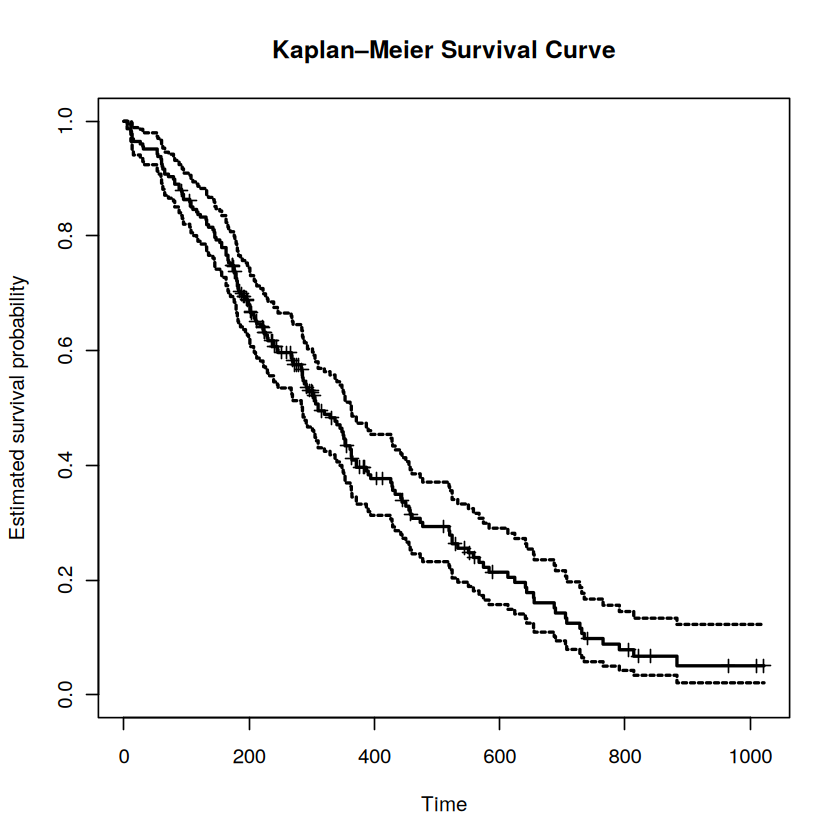

In [2]:


km_fit <- survfit(Surv(time, status) ~ 1, data = lung)

plot(
  km_fit,
  xlab = "Time",
  ylab = "Estimated survival probability",
  main = "Kaplan–Meier Survival Curve",
  mark.time = TRUE,
  conf.int = TRUE,
  lwd = 2
)




The estimated survival probability declines over follow-up as deaths occur. The widening confidence interval toward the right-hand tail reflects the decreasing number of individuals remaining under observation.
### Quantifying Uncertainty: Greenwood's Formula

The Kaplan–Meier estimator provides a **point estimate** of the survival probability. As with any statistical estimate, however, we also want to know **how precise** that estimate is.

The uncertainty of the Kaplan–Meier estimator is estimated using **Greenwood's formula**, which provides an estimate of its variance:


$$
\widehat{\mathrm{Var}}{\hat S(t)}
=\hat S(t)^2
\sum_{t_j\le t}
\frac{d_j}
{n_j(n_j-d_j)}.
$$

Taking the square root gives the estimated standard error:

$$
\widehat{\mathrm{SE}}{\hat S(t)}
=\hat S(t)
\sqrt{
\sum_{t_j\le t}
\frac{d_j}
{n_j(n_j-d_j)}
}.
$$

Each observed event contributes one term to the summation. As follow-up continues and fewer individuals remain in the risk set, the uncertainty of the survival estimate generally increases. This is why confidence intervals around Kaplan–Meier curves typically become wider toward the end of a study.

### Implementing Greenwood's Formula

Just as we manually computed the Kaplan–Meier estimator, we can also compute its standard error directly from Greenwood's formula.

At each event time we:

1. Update the Kaplan–Meier survival estimate.
2. Add the Greenwood variance contribution
   $$
   \frac{d_j}{n_j(n_j-d_j)}
   $$
   to a running cumulative sum.
3. Multiply the accumulated variance term by the current survival estimate to obtain the standard error.

The implementation below follows these three steps directly.

In [3]:
# Manual Greenwood standard error
S <- 1
cum_var_term <- 0

km_manual$se <- NA

for (i in seq_along(event_times)) {

  n_j <- km_manual$n[i]
  d_j <- km_manual$d[i]

  # Update Kaplan–Meier estimate
  S <- S * (1 - d_j / n_j)

  # Greenwood variance contribution
  cum_var_term <- cum_var_term +
    d_j / (n_j * (n_j - d_j))

  # Standard error
  km_manual$se[i] <- S * sqrt(cum_var_term)

}

km_manual[, c("time", "S", "se")]

time,S,se
<dbl>,<dbl>,<dbl>
4,0.9000000,0.09486833
6,0.8000000,0.12649111
8,0.6857143,0.15149402
10,0.5485714,0.17243785
14,0.1828571,0.15998445


We can now compare both the manually calculated survival probabilities and their standard errors with the values returned by `survfit()`.


In [4]:
comparison <- data.frame(
  time = summary(fit)$time,
  manual_surv = km_manual$S,
  survfit_surv = summary(fit)$surv,
  manual_se = km_manual$se,
  survfit_se = summary(fit)$std.err
)
comparison

time,manual_surv,survfit_surv,manual_se,survfit_se
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4,0.9000000,0.9000000,0.09486833,0.09486833
6,0.8000000,0.8000000,0.12649111,0.12649111
8,0.6857143,0.6857143,0.15149402,0.15149402
10,0.5485714,0.5485714,0.17243785,0.17243785
14,0.1828571,0.1828571,0.15998445,0.15998445


The manually calculated survival probabilities and standard errors should match those returned by `survfit()` to numerical precision. This demonstrates that the Kaplan–Meier estimator and Greenwood's standard error are not separate algorithms, but rather direct implementations of the mathematical formulas derived above.

## The Cox Proportional Hazards Model

The Kaplan–Meier estimator is an excellent tool for estimating the survival probability of a group over time. However, it has one important limitation: it cannot simultaneously evaluate the effect of multiple variables on survival.

Suppose we want to answer questions such as:

* Does age increase the risk of death?
* Is a new treatment more effective than the standard treatment?
* Does smoking shorten survival after accounting for age?
* Do specific genetic variants influence disease progression?

These questions involve **covariates**—variables that may influence the time until an event occurs. While Kaplan–Meier curves can compare a few predefined groups (for example, treated versus untreated patients), they cannot quantify the effect of several predictors simultaneously.

To address this problem, Sir David Cox introduced the **Cox proportional hazards model** in 1972. Rather than modeling the survival probability directly, the Cox model describes **how covariates influence the hazard**, or instantaneous risk, of experiencing the event.

### The Cox Model

For an individual with covariate vector $X_i$, the hazard function is written as

$$
h_i(t \mid X_i)
=h_0(t)\exp(\beta^T X_i),
$$

where

* $h_i(t)$ is the hazard for individual $i$,
* $h_0(t)$ is the **baseline hazard**, representing the hazard when all covariates are at their reference values,
* $X_i$ is the vector of observed covariates (such as age, sex, or treatment),
* $\beta$ is the vector of regression coefficients describing how each covariate affects the hazard.

The exponential function ensures that the hazard remains positive while allowing covariates to increase or decrease the risk multiplicatively.

---

### Hazard Ratios

One of the most attractive features of the Cox model is that we can compare two individuals without knowing the baseline hazard.

Suppose individuals **A** and **B** have covariate vectors $X_A$ and $X_B$. Their hazard ratio is

$$
\frac{h(t\mid X_A)}
{h(t\mid X_B)}
=\exp{\beta^T(X_A-X_B)}.
$$

Notice that the baseline hazard $h_0(t)$ cancels completely.

This means that the Cox model estimates **relative risk**, rather than absolute risk.

For example, if

$$
\exp(\beta)=2,
$$

then one individual has **twice the instantaneous risk** of experiencing the event compared with another individual who differs by one unit in that covariate.

---

### Why Is It Called the Proportional Hazards Model?

The hazard ratio above does **not** depend on time.

Regardless of whether the baseline hazard increases, decreases, or fluctuates during follow-up, the ratio between two individuals remains constant:

$$
\frac{h(t\mid X_A)}
{h(t\mid X_B)}
=\text{constant}.
$$

This assumption is known as the **proportional hazards assumption**, and it gives the model its name.

Importantly, this is an **assumption**, not a mathematical guarantee. In practice, it should always be assessed after fitting the model, most commonly using **Schoenfeld residuals**, which we will discuss later.

---

### Cox's Key Insight: The Partial Likelihood

At first glance, estimating the regression coefficients appears difficult because the baseline hazard $h_0(t)$ is completely unknown.

Cox's key insight was that we do not actually need to estimate the baseline hazard in order to estimate the regression coefficients.

Instead of modeling the full likelihood, he considered the probability that, among all individuals still at risk at an observed event time, the individual who actually experienced the event was the one who failed.

Suppose individual $i_j$ experiences the event at time $t_j$, and let $R(t_j)$ denote the **risk set**—the individuals still under observation immediately before that event time.

The conditional probability that individual $i_j$ experiences the event is

$$
P(i_j\text{ fails at }t_j
\mid
\text{one failure in }R(t_j))
=\frac{\exp(\beta^T X_{i_j})}
{\sum_{l\in R(t_j)}
\exp(\beta^T X_l)}.
$$

Remarkably, the unknown baseline hazard cancels from this expression, just as it did in the hazard ratio.

Multiplying these conditional probabilities across all observed event times produces the **partial likelihood**:

$$
L_p(\beta)
=\prod_{j=1}^{k}
\frac{\exp(\beta^T X_{i_j})}
{\sum_{l\in R(t_j)}
\exp(\beta^T X_l)}.
$$

Unlike an ordinary likelihood, the partial likelihood contains only the regression coefficients and no baseline hazard, making estimation much simpler.

---

### Estimating the Regression Coefficients

To estimate the regression coefficients, we maximize the **log partial likelihood** numerically.

This produces the estimate

$$
\hat{\beta},
$$

which quantifies the effect of each covariate on the hazard.

Modern statistical software performs this optimization automatically. In R, the `coxph()` function from the **survival** package fits the Cox proportional hazards model using this partial likelihood approach.

To better understand how the method works, the following example first implements the log partial likelihood directly from its mathematical definition and optimizes it using `optim()`. We then compare the manually estimated regression coefficients with those returned by `coxph()` using the `lung` dataset and two covariates: **age** and **sex**.



### Implementing the Cox Partial Likelihood by Hand

We now implement the Cox partial likelihood directly from its mathematical definition. We use the `lung` dataset from the **survival** package and model survival using age and sex.

In the original dataset:

* `status = 1` indicates censoring and `status = 2` indicates death.
* `sex = 1` indicates male and `sex = 2` indicates female.

We recode both variables into a more conventional binary form:

* `status = 0` for censored and `status = 1` for an observed event.
* `sex = 0` for male and `sex = 1` for female.

In [5]:

lung2 <- na.omit(lung[, c("time", "status", "age", "sex")])

lung2$status <- lung2$status - 1   # 0 = censored, 1 = event
lung2$sex    <- lung2$sex - 1      # 0 = male, 1 = female


The function below calculates the negative log partial likelihood. For each distinct event time, it identifies:

* the individuals still in the risk set,
* the individuals experiencing the event,
* the linear predictor $\beta^T X$ for everyone in the risk set.

It then adds each event's contribution to the log partial likelihood:

$$
\ell_p(\beta)
=\sum_{j}\left[\beta^T X_{i_j}-\log\left{\sum_{l\in R(t_j)}\exp(\beta^T X_l)\right}\right].
$$

In [6]:

# Negative log partial likelihood
neg_log_pl <- function(beta, data) {

  X <- as.matrix(data[, c("age", "sex")])
  time <- data$time
  status <- data$status

  event_times <- sort(unique(time[status == 1]))

  log_partial_likelihood <- 0

  for (tj in event_times) {

    # Individuals still at risk immediately before tj
    risk_idx <- which(time >= tj)

    # Individuals experiencing the event at tj
    event_idx <- which(time == tj & status == 1)

    # Linear predictors for the risk set
    linear_predictor <- as.vector(
      X[risk_idx, , drop = FALSE] %*% beta
    )

    # Add one contribution for each event at tj
    for (i in event_idx) {

      log_partial_likelihood <-
        log_partial_likelihood +
        sum(X[i, ] * beta) -
        log(sum(exp(linear_predictor)))
    }
  }

  # optim() minimizes, so return the negative value
  -log_partial_likelihood
}






We use `optim()` to minimize the negative log partial likelihood. The Hessian matrix returned by the optimizer provides an estimate of the covariance matrix of the regression coefficients.


In [7]:

fit_manual <- optim(
  par = c(0, 0),
  fn = neg_log_pl,
  data = lung2,
  method = "BFGS",
  hessian = TRUE
)

beta_manual <- setNames(
  fit_manual$par,
  c("age", "sex")
)

se_manual <- setNames(
  sqrt(diag(solve(fit_manual$hessian))),
  c("age", "sex")
)

round(beta_manual, 4)
round(se_manual, 4)


age     sex 
 0.0170 -0.5126

age    sex 
0.0092 0.1675


### Handling Tied Event Times

In real survival datasets, multiple individuals may experience the event at exactly the same recorded time. These are called **tied events**.

The manual implementation above uses the **Breslow approximation**: all events occurring at the same time share the same risk-set denominator.

To make the comparison technically consistent, we must therefore instruct `coxph()` to use the same method:

In [8]:
fit_cox <- coxph(
  Surv(time, status) ~ age + sex,
  data = lung2,
  ties = "breslow"
)

summary(fit_cox)

Call:
coxph(formula = Surv(time, status) ~ age + sex, data = lung2, 
    ties = "breslow")

  n= 228, number of events= 165 

         coef exp(coef)  se(coef)      z Pr(>|z|)   
age  0.017013  1.017158  0.009222  1.845  0.06506 . 
sex -0.512565  0.598957  0.167462 -3.061  0.00221 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

    exp(coef) exp(-coef) lower .95 upper .95
age     1.017     0.9831    0.9989    1.0357
sex     0.599     1.6696    0.4314    0.8316

Concordance= 0.603  (se = 0.025 )
Likelihood ratio test= 14.08  on 2 df,   p=9e-04
Wald test            = 13.44  on 2 df,   p=0.001
Score (logrank) test = 13.69  on 2 df,   p=0.001


We can compare the manually estimated coefficients and standard errors with those returned by `coxph()`:


In [9]:
comparison <- data.frame(
  term = c("age", "sex"),
  manual_beta = as.numeric(beta_manual),
  coxph_beta = as.numeric(coef(fit_cox)),
  manual_se = as.numeric(se_manual),
  coxph_se = as.numeric(sqrt(diag(vcov(fit_cox))))
)

comparison[, -1] <- round(comparison[, -1], 4)

comparison


term,manual_beta,coxph_beta,manual_se,coxph_se
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
age,0.0170,0.0170,0.0092,0.0092
sex,-0.5126,-0.5126,0.1675,0.1675



The manual and `coxph()` estimates should agree closely because both calculations now use the same partial likelihood and the same method for handling tied event times.

The fitted coefficients are expressed on the **log-hazard scale**. Exponentiating them gives the corresponding hazard ratios:

In [10]:
exp(beta_manual)
exp(coef(fit_cox))


age       sex 
1.0171586 0.5989552

age       sex 
1.0171584 0.5989574


For age, the hazard ratio represents the multiplicative change in the hazard associated with a one-year increase in age, holding sex constant.

For sex, the hazard ratio compares females (`sex = 1`) with males (`sex = 0`), holding age constant. A hazard ratio below 1 indicates a lower estimated hazard for females than for males.


The manually estimated coefficients and standard errors agree with those returned by `coxph()` to several decimal places. Because both implementations use the Breslow method for tied event times, the very small remaining differences are due only to numerical optimization and floating-point precision.

### Interpreting the Cox Coefficients

The coefficients produced by a Cox model are expressed on the **log-hazard scale**. Exponentiating a coefficient converts it into a hazard ratio:

$$
\mathrm{HR}=\exp(\beta).
$$

A hazard ratio greater than 1 indicates a higher estimated hazard, while a hazard ratio below 1 indicates a lower estimated hazard, holding the other covariates fixed.

For age, the estimated coefficient is approximately

$$
\hat\beta_{\text{age}}=0.017.
$$

Exponentiating gives

$$
\exp(0.017)\approx1.017.
$$

This means that each additional year of age is associated with an estimated **1.7% increase in the instantaneous hazard of death**, holding sex constant.

The effect appears small because the coefficient describes a one-year difference. Over a ten-year age difference, the corresponding hazard ratio is

$$
\exp(10\times0.017)\approx1.19.
$$

Thus, a patient who is ten years older has an estimated hazard approximately 19% higher, assuming the proportional hazards model is appropriate and the other covariates remain fixed.

For sex, coded as

* `0 = male`,
* `1 = female`,

the estimated coefficient is approximately

$$
\hat\beta_{\text{sex}}=-0.513.
$$

The corresponding hazard ratio is

$$
\exp(-0.513)\approx0.60.
$$

Therefore, female patients in this cohort have an estimated hazard of death approximately **0.60 times that of male patients**, after adjusting for age. Equivalently, this corresponds to an estimated **40% lower hazard**:

$$
1-0.60=0.40.
$$

These interpretations describe associations within this dataset. They should not automatically be interpreted as causal effects.

### Standard Errors from the Information Matrix

Estimating the coefficients is only part of the analysis. We also need to quantify their uncertainty.

Let

$$
\ell_p(\beta)
$$

denote the Cox log partial likelihood. The observed information matrix is

$$
I(\beta)
=-\frac{\partial^2\ell_p(\beta)}
{\partial\beta,\partial\beta^T}.
$$

The estimated covariance matrix of the fitted coefficients is obtained by inverting the observed information matrix at the estimated parameter values:

$$
\widehat{\mathrm{Var}}(\hat\beta)
=I(\hat\beta)^{-1}.
$$

The standard error of each coefficient is then the square root of the corresponding diagonal element:

$$
\mathrm{SE}(\hat\beta_j)
=\sqrt{
\left[
I(\hat\beta)^{-1}
\right]_{jj}
}.
$$

In our implementation, `optim()` minimizes the **negative log partial likelihood**. Therefore, when `hessian = TRUE`, the returned Hessian is already the observed information matrix:

In [11]:
information_matrix <- fit_manual$hessian

covariance_matrix <- solve(information_matrix)

se_manual <- sqrt(diag(covariance_matrix))


This means the same optimization procedure provides both

* the coefficient estimates, through the location of the minimum, and
* their estimated uncertainty, through the curvature of the objective function around that minimum.

A sharply curved likelihood produces smaller standard errors and more precise coefficient estimates. A flatter likelihood produces larger standard errors, indicating greater uncertainty about the fitted effects.


## Residual Diagnostics in the Cox Model

In ordinary linear regression, residuals are easy to define—they are simply the difference between the observed and predicted values of the response variable.

Survival analysis is different. Because many observations are **censored**, we often do not know the true event time for every individual. Consequently, there is no single "raw residual" analogous to that used in linear regression.

Instead, the Cox proportional hazards model uses several specialized residuals, each designed to answer a different diagnostic question. Among the most commonly used are:

* **Martingale residuals**, used to assess model fit and detect nonlinearity in covariate effects.
* **Deviance residuals**, a transformation of martingale residuals that is more symmetric and useful for identifying outliers.
* **Schoenfeld residuals**, used to assess the proportional hazards assumption.
* **Scaled Schoenfeld residuals**, commonly used in formal tests of proportional hazards, such as the `cox.zph()` test in R.

### Martingale Residuals

The **martingale residual** compares what was actually observed with what the fitted Cox model expected for each individual.

It is defined as

$$
M_i
=\delta_i \widehat{H}_0(t_i)
\exp(\hat\beta^T X_i),
$$

where

* $\delta_i$ is the event indicator (1 = event, 0 = censored),
* $\widehat{H}_0(t_i)$ is the estimated **baseline cumulative hazard** evaluated at the observed follow-up time,
* $X_i$ is the individual's covariate vector,
* $\hat\beta$ is the vector of estimated regression coefficients.

The estimated baseline cumulative hazard is usually obtained using the **Breslow estimator**,

$$
\widehat{H}_0(t)
=\sum_{t_j\le t}
\frac{d_j}
{\sum_{l\in R(t_j)}
\exp(\hat\beta^T X_l)},
$$

where

* $d_j$ is the number of events at time $t_j$, and
* $R(t_j)$ is the risk set immediately before time $t_j$.

Notice that the martingale residual is simply

> **Observed events − Expected cumulative hazard**

making it conceptually similar to an observed-minus-expected residual used in many statistical models.

### Interpreting Martingale Residuals

Martingale residuals have some unusual mathematical properties.

* They are **bounded above by 1**.
* They are **unbounded below**.
* Their distribution is often highly skewed.

A positive residual indicates that fewer events were expected than observed for that individual.

A large negative residual indicates that the individual survived substantially longer than the model predicted based on their covariates.

Because of their asymmetry, martingale residuals are **not ideal for identifying outliers directly**. Instead, they are primarily used to assess whether the functional form of a continuous covariate is appropriate.

For example, after fitting a Cox model with age as a linear predictor, one can plot the martingale residuals against age. If the residuals exhibit a systematic curved pattern rather than random scatter, this suggests that the effect of age may not be linear and that a transformation or spline term could provide a better fit.

In R, martingale residuals can be obtained directly from a fitted Cox model using



In [12]:
martingale_residuals <- residuals(fit_cox, type = "martingale")


In the next section, we will examine **Schoenfeld residuals**, which play a different role: testing whether the proportional hazards assumption underlying the Cox model is satisfied.

### Computing Martingale Residuals by Hand

We can reproduce the martingale residuals returned by `coxph()` by calculating the Breslow baseline cumulative hazard directly.

First, we extract the fitted coefficients and calculate each individual's relative hazard:

In [13]:
beta_hat <- coef(fit_cox)

X <- as.matrix(
  lung2[, c("age", "sex")]
)

relative_hazard <- as.vector(
  exp(X %*% beta_hat)
)


Next, we estimate the baseline cumulative hazard using the Breslow estimator:

$$
\widehat H_0(t)
=\sum_{t_j\le t}
\frac{d_j}
{\sum_{l\in R(t_j)}
\exp(\hat\beta^T X_l)}.
$$

In [14]:
# Distinct observed event times
event_times <- sort(
  unique(lung2$time[lung2$status == 1])
)

# Breslow baseline cumulative hazard
H0 <- numeric(length(event_times))
cumulative_hazard <- 0

for (j in seq_along(event_times)) {

  tj <- event_times[j]

  # Number of events at tj
  d_j <- sum(
    lung2$time == tj &
    lung2$status == 1
  )

  # Individuals in the risk set at tj
  risk_set <- lung2$time >= tj

  # Breslow increment
  hazard_increment <-
    d_j / sum(relative_hazard[risk_set])

  cumulative_hazard <-
    cumulative_hazard + hazard_increment

  H0[j] <- cumulative_hazard
}



The cumulative baseline hazard is a step function. For each individual, we therefore need the value corresponding to the most recent event time at or before their observed follow-up time.

Before the first event, the cumulative hazard must equal zero.

In [15]:
# Locate the final event time at or before each observed time
interval_index <- findInterval(
  lung2$time,
  event_times
)

# Evaluate H0(t) at each individual's observed follow-up time
H0_at_Y <- ifelse(
  interval_index == 0,
  0,
  H0[interval_index]
)




The expected cumulative number of events for individual (i) is

$$
\widehat H_0(Y_i)
\exp(\hat\beta^T X_i).
$$

The martingale residual is therefore

$$
M_i
=\delta_i \widehat H_0(Y_i)
\exp(\hat\beta^T X_i).
$$

In [16]:
martingale_manual <-
  lung2$status -
  H0_at_Y * relative_hazard

We can compare the manual calculation with the residuals returned by `coxph()`:


In [17]:
martingale_coxph <- residuals(
  fit_cox,
  type = "martingale"
)

comparison <- data.frame(
  manual = martingale_manual,
  coxph = as.numeric(martingale_coxph),
  difference = martingale_manual -
    as.numeric(martingale_coxph)
)

head(
  transform(
    comparison,
    manual = round(manual, 4),
    coxph = round(coxph, 4),
    difference = round(difference, 8)
  )
)

,manual,coxph,difference
,<dbl>,<dbl>,<dbl>
1,0.0062,0.0062,0
2,-0.5030,-0.5030,0
3,-3.1272,-3.1272,0
4,0.5335,0.5335,0
5,-2.3474,-2.3474,0
6,-4.2477,-4.2477,0


The two sets of residuals should agree to numerical precision, provided that `fit_cox` was fitted using the Breslow method:


### Schoenfeld Residuals

Whereas martingale residuals assess the fit of individual observations, **Schoenfeld residuals** are used to assess the **proportional hazards assumption**. At each observed event time \(t_j\), the Schoenfeld residual is defined as the difference between the covariate value of the individual who experienced the event and the risk-set-weighted average covariate value:

$$
r_j = X_{i_j} - \bar X(\hat\beta, t_j), \qquad
\bar X(\hat\beta, t_j)
=\frac{\sum_{l \in R(t_j)} X_l \exp(\hat\beta^T X_l)}
{\sum_{l \in R(t_j)} \exp(\hat\beta^T X_l)}.
$$

There is **one Schoenfeld residual for each event and each covariate**, rather than one residual per individual. If the proportional hazards assumption holds, these residuals should show **no systematic trend** when plotted against time.

### Computing Schoenfeld Residuals in R

The `survival` package computes Schoenfeld residuals directly from a fitted Cox model. The residual matrix has **one row for each observed event** and **one column for each covariate**.



In [18]:

sch <- residuals(fit_cox, type = "schoenfeld")

dim(sch)
head(sch)

[1] 165   2

,age,sex
5,0.9382653,0.7269349
11,9.9412847,-0.2707258
11,16.9412847,-0.2707258
11,2.9412847,-0.2707258
12,10.1431920,-0.2759338
13,12.2083432,-0.2777061


In practice, the proportional hazards assumption is usually assessed by plotting the **scaled Schoenfeld residuals** against event time and testing whether their slope differs significantly from zero. In R, the `cox.zph()` function performs both the graphical diagnostic and the corresponding statistical test.

Deviance residuals, Cox–Snell residuals, and DFBETAs are additional diagnostic measures derived from the same martingale and score-function framework. They are useful for identifying outliers, assessing overall model fit, and evaluating influential observations, and are beyond the scope of this tutorial.


### Comparing Survival Between Groups

Before performing the log-rank test, the group-specific Kaplan–Meier curves provide a visual summary of the survival difference.


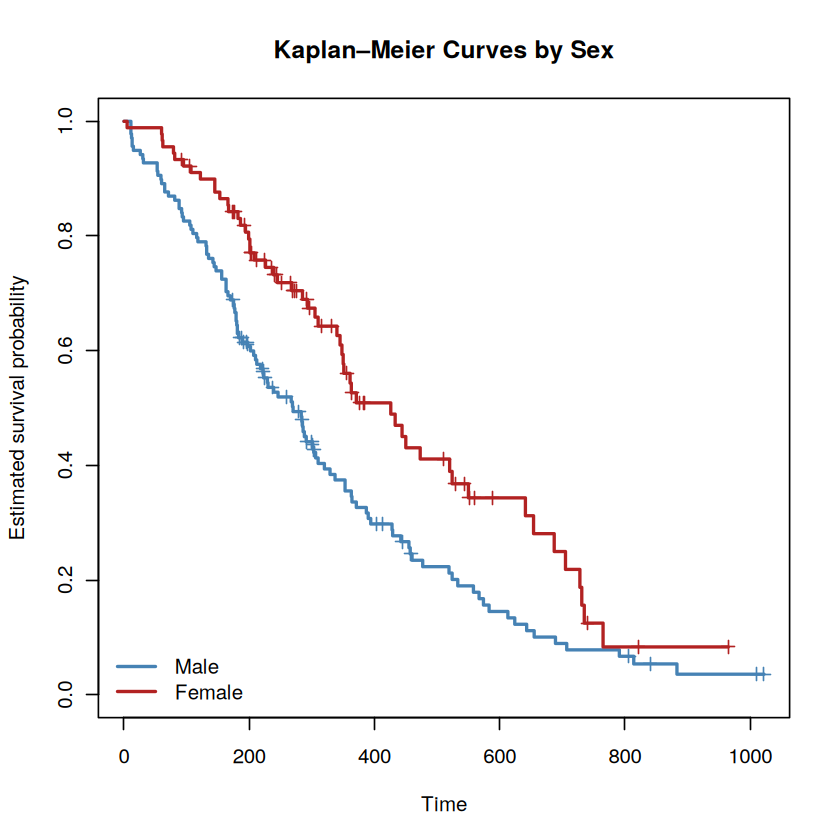

In [19]:


km_sex <- survfit(Surv(time, status) ~ sex, data = lung2)

plot(
  km_sex,
  xlab = "Time",
  ylab = "Estimated survival probability",
  main = "Kaplan–Meier Curves by Sex",
  mark.time = TRUE,
  lwd = 2,
  col = c("steelblue", "firebrick")
)

legend(
  "bottomleft",
  legend = c("Male", "Female"),
  col = c("steelblue", "firebrick"),
  lwd = 2,
  bty = "n"
)




The separation between the curves gives an immediate visual impression of the group difference, while the log-rank test formally evaluates whether the survival experiences differ over follow-up.

## The Log-Rank Test

The **log-rank test** is the most widely used statistical test for comparing survival curves between two or more groups. Unlike the Cox proportional hazards model, it does **not** estimate regression coefficients or require covariates. Instead, it tests the null hypothesis that the groups have the same underlying survival experience.

At each observed event time, the test compares the **observed** number of events in each group with the **expected** number of events under the null hypothesis of equal survival.

Mathematically,

$$
O_1 - E_1
=\sum_{j=1}^{k}
\left(
d_{1j}
-\frac{n_{1j}}{n_j}d_j
\right),
$$

where

- $d_{1j}$ is the number of observed events in Group 1 at event time $t_j$,
- $n_{1j}$ is the number of individuals at risk in Group 1 just before $t_j$,
- $d_j$ is the total number of events at $t_j$,
- $n_j$ is the total number of individuals at risk at $t_j$.

The variance of the observed-minus-expected statistic is

$$
\mathrm{Var}(O_1-E_1)
=\sum_{j=1}^{k}
\frac{
n_{1j}n_{2j}\,
d_j(n_j-d_j)
}{
n_j^2(n_j-1)
}.
$$

The log-rank test statistic is then

$$
Z^2
=
\frac{(O_1-E_1)^2}
{\mathrm{Var}(O_1-E_1)},
$$

which follows approximately a chi-squared distribution with one degree of freedom under the null hypothesis.

> **Why does this look familiar?**
>
> The log-rank test is built from exactly the same **risk-set bookkeeping** used by the Kaplan–Meier estimator. At each event time, we count how many individuals remain at risk ($n_j$) and how many events occur ($d_j$). The only difference is that the log-rank test performs these calculations separately for each group and compares the observed and expected numbers of events over the entire follow-up period.

### Implementing the Log-Rank Test by Hand

To illustrate the calculation, we divide the `lung` dataset into two groups using the median age:

- `old`: age above the median,
- `young`: age at or below the median.

At each observed event time, the code calculates the numbers at risk and the observed events in the older group, then accumulates the observed count, expected count, and variance across follow-up.


In [20]:

lung3 <- na.omit(lung[, c("time", "status", "age")])

lung3$status <- lung3$status - 1
lung3$agegrp <- ifelse(
  lung3$age > median(lung3$age),
  "old",
  "young"
)

event_times <- sort(
  unique(lung3$time[lung3$status == 1])
)

O1 <- 0
E1 <- 0
V  <- 0

for (tj in event_times) {

  # Individuals at risk immediately before tj
  risk_idx <- which(lung3$time >= tj)

  n_j  <- length(risk_idx)
  n1j  <- sum(lung3$agegrp[risk_idx] == "old")
  n2j  <- n_j - n1j

  # Total events and events in the older group at tj
  d_j <- sum(
    lung3$time == tj &
    lung3$status == 1
  )

  d1j <- sum(
    lung3$time == tj &
    lung3$status == 1 &
    lung3$agegrp == "old"
  )

  # Accumulate observed and expected events
  O1 <- O1 + d1j
  E1 <- E1 + (n1j / n_j) * d_j

  # Accumulate the variance
  if (n_j > 1) {
    V <- V +
      (n1j * n2j * d_j * (n_j - d_j)) /
      (n_j^2 * (n_j - 1))
  }
}

Z2 <- (O1 - E1)^2 / V

c(
  O1 = O1,
  E1 = round(E1, 3),
  Var = round(V, 3),
  Z2 = round(Z2, 3)
)



O1     E1    Var     Z2 
85.000 76.237 40.821  1.881

Here, \(O_1\) is the total number of observed events in the older group, \(E_1\) is the number expected under equal survival, and \(Z^2\) is the log-rank chi-squared statistic.

We can compare the manual result with R's `survdiff()` function:


In [21]:




fit_logrank <- survdiff(
  Surv(time, status) ~ agegrp,
  data = lung3
)

fit_logrank

c(
  manual_Z2 = Z2,
  survdiff_Z2 = fit_logrank$chisq
)




Call:
survdiff(formula = Surv(time, status) ~ agegrp, data = lung3)

               N Observed Expected (O-E)^2/E (O-E)^2/V
agegrp=old   111       85     76.2     1.007      1.88
agegrp=young 117       80     88.8     0.865      1.88

 Chisq= 1.9  on 1 degrees of freedom, p= 0.2 

manual_Z2 survdiff_Z2 
   1.880999    1.880999

The two chi-squared statistics should agree to numerical precision.

## A Full Proportional-Hazards Diagnostic Workflow

The residuals introduced above are the raw material. Used together, in a fixed order, they form a standard diagnostic workflow for a fitted Cox model: does the model fit at all (Cox–Snell), are there poorly-fit or influential individuals (deviance), and does the proportional hazards assumption actually hold (`cox.zph`).

### Deviance residuals

Martingale residuals are useful but skewed: they range over $(-\infty, 1]$, so a handful of extreme negative values can dominate a plot. Deviance residuals are a variance-stabilizing transform of the martingale residual $M_i$:

$$
D_i = \text{sign}(M_i)\sqrt{-2\left[M_i + \delta_i \log(\delta_i - M_i)\right]}.
$$

> **Why bother transforming at all?**
> $D_i$ is approximately symmetric around 0 for a well-fitting model, the way ordinary residuals are in linear regression. That makes them far more useful than martingale residuals for spotting individual outliers by eye.


In [22]:
dev_manual <- sign(martingale_manual) *
  sqrt(pmax(0, -2 * (martingale_manual + lung2$status * log(lung2$status - martingale_manual))))
dev_coxph <- residuals(fit_cox, type = "deviance")

round(head(cbind(manual = dev_manual, coxph = dev_coxph)), 4)

,manual,coxph
1,0.0062,0.0062
2,-0.4371,-0.4371
3,-2.5009,-2.5009
4,0.6767,0.6767
5,-1.5095,-1.5095
6,-2.9147,-2.9147


The manually computed deviance residuals match those returned by `coxph()`. Plotting deviance residuals against the linear predictor \(\eta = X\hat\beta\) is a standard diagnostic for identifying potential outliers and assessing model fit.

Plotting the deviance residuals against the fitted linear predictor provides a simple visual check for unusual observations or systematic departures from the fitted Cox model.



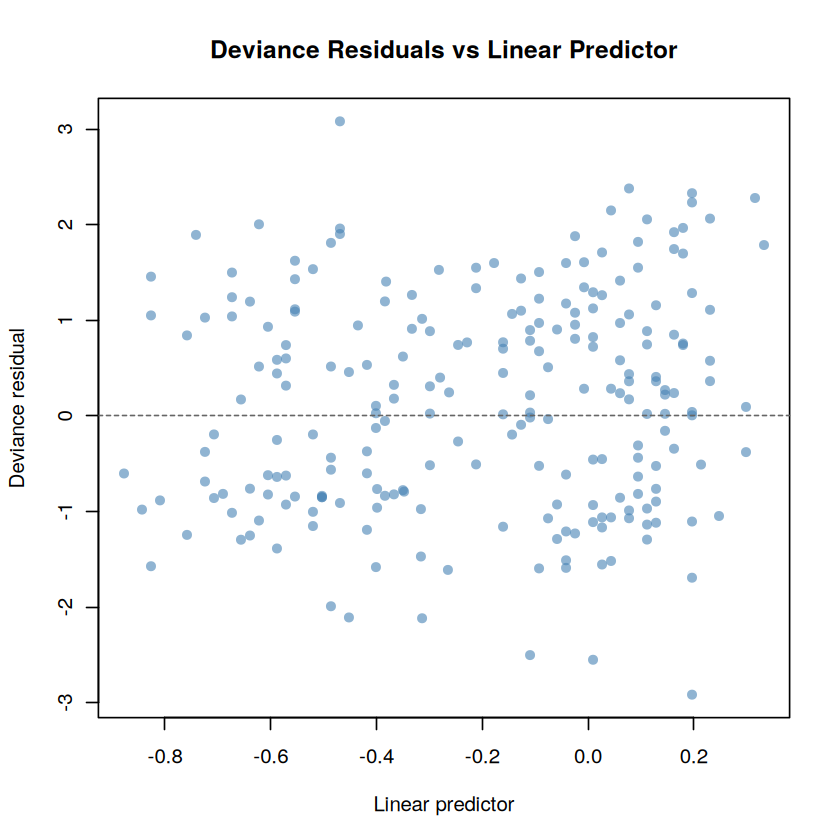

In [23]:

lp <- predict(fit_cox, type = "lp")

plot(
  lp,
  dev_coxph,
  pch = 16,
  col = adjustcolor("steelblue", 0.6),
  xlab = "Linear predictor",
  ylab = "Deviance residual",
  main = "Deviance Residuals vs Linear Predictor"
)

abline(h = 0, lty = 2, col = "grey40")




As you can see, the residuals are scattered roughly symmetrically around zero, with no obvious trend or a small number of extreme outlying observations.

No individual sits far outside the band formed by the rest, and there is no visible curvature — no sign that a transformation of `age` or `sex` is needed.

### Cox–Snell residuals

Cox–Snell residuals check overall model fit rather than individual fit. For a correctly specified model, the residual

$$
R_i = \hat H_0(Y_i)\exp(\hat\beta^T X_i)
$$

should behave like a censored sample from an $\text{Exponential}(1)$ distribution — because $R_i$ is just $\hat\Lambda_i(Y_i)$, and the cumulative hazard of any survival time evaluated at itself is exponential with rate 1.

> **How is that checked in practice?**
> Treat $\{R_i, \delta_i\}$ as a new survival dataset and estimate its own Kaplan–Meier cumulative hazard, $-\log \hat S_R(r)$. If the original model fits well, this cumulative hazard should trace the 45° line $y = r$, since that is the cumulative hazard of a unit-rate exponential.

Conveniently, $R_i = \delta_i - M_i$, so no separate calculation is needed beyond the martingale residuals already computed.


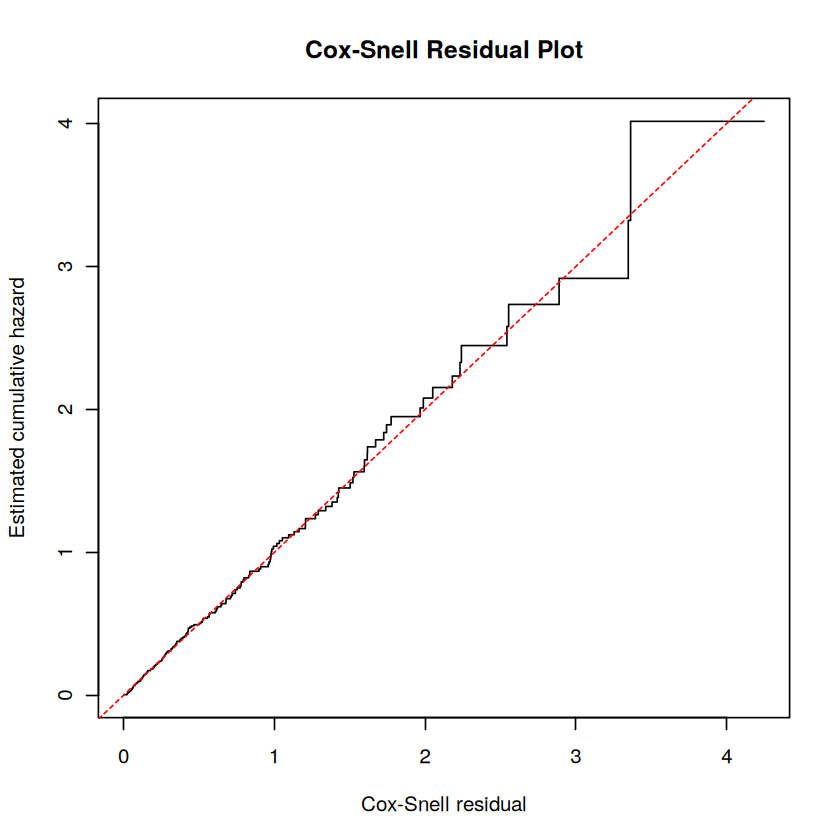

In [24]:
coxsnell <- lung2$status - martingale_manual   # R_i = delta_i - M_i
cs_fit <- survfit(Surv(coxsnell, lung2$status) ~ 1)

plot(cs_fit$time, -log(cs_fit$surv), type = "s",
     xlab = "Cox-Snell residual", ylab = "Estimated cumulative hazard",
     main = "Cox-Snell Residual Plot")
abline(0, 1, col = "red", lty = 2)

The step function tracks the reference line closely apart from some flattening in the right tail, where only a handful of individuals remain at risk and the empirical cumulative hazard becomes noisy by construction. This is the expected pattern for an adequately fitting Cox model, rather than evidence of poor fit.

### Testing Proportional Hazards with `cox.zph()`

Schoenfeld residuals were introduced earlier as raw per-event quantities. `cox.zph()` turns them into a formal test by examining whether the **scaled Schoenfeld residuals** vary systematically with a transformation of event time. By default, it uses a Kaplan–Meier transformation of time and tests whether the estimated time-dependent trend is zero.

> **What does a significant result mean?**
>
> A small p-value for a covariate indicates that its estimated effect on the hazard changes over follow-up time. In other words, the proportional hazards assumption may be violated for that covariate. The `GLOBAL` test evaluates the proportional hazards assumption for all covariates jointly.

In [25]:
zph_fit <- cox.zph(fit_cox)
zph_fit

       chisq df    p
age    0.208  1 0.65
sex    2.599  1 0.11
GLOBAL 2.761  2 0.25

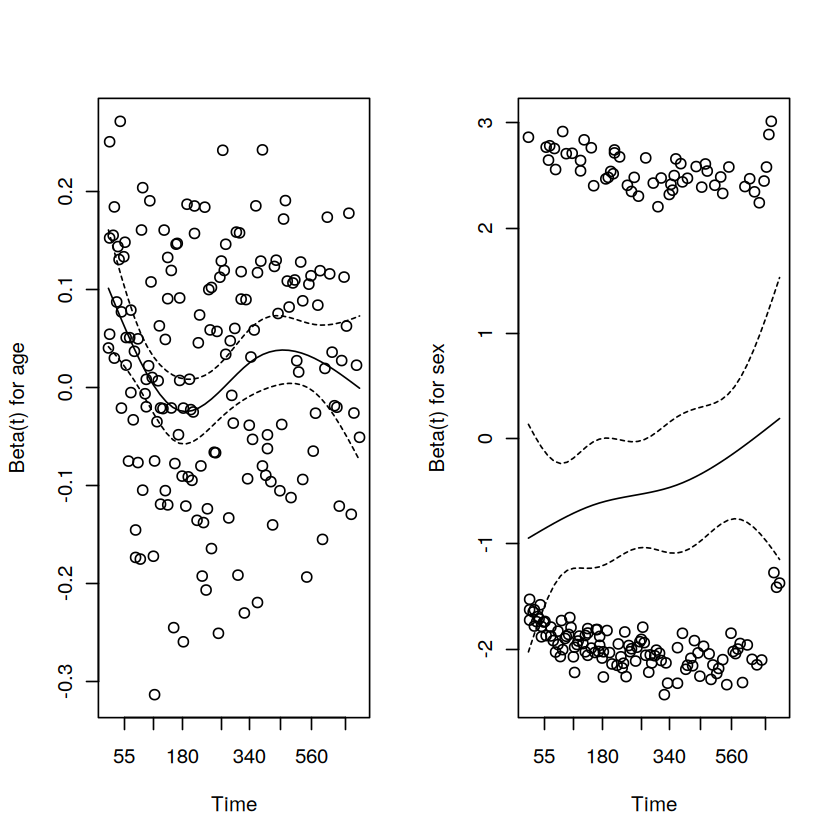

In [26]:
par(mfrow = c(1, 2))
plot(zph_fit)

Neither covariate shows evidence of a violation of the proportional hazards assumption (age: \(p = 0.65\); sex: \(p = 0.11\); global test: \(p = 0.25\)). In both panels, the smoothed curves remain approximately horizontal and fluctuate around zero throughout follow-up. The proportional hazards assumption therefore appears reasonable for this model, and the estimated hazard ratios can be interpreted as approximately constant over the observed follow-up period.

### Putting the workflow together

For a fitted Cox model, the same three checks apply in the same order every time:

1. **Cox–Snell residuals** — does the model fit overall? Compare their cumulative hazard to the 45° line.
2. **Deviance residuals** — which individuals fit badly? Plot against the linear predictor and scan for outliers or curvature.
3. **`cox.zph()`** — does proportional hazards hold, covariate by covariate? A significant result flags exactly which covariate needs a time-varying effect or stratification.


## Summary

Kaplan–Meier estimation and Cox proportional hazards regression are built on the same counting-process framework but estimate different quantities.

- **Kaplan–Meier** estimates the survival function \(S(t)\) directly as a product of conditional survival probabilities at each observed event time, with Greenwood's formula providing its standard error.

- **Cox proportional hazards regression** models the hazard as
  \[
  h(t \mid X)=h_0(t)\exp(\beta^T X),
  \]
  and estimates \(\beta\) by maximizing the partial likelihood, which eliminates the unspecified baseline hazard by conditioning on the risk set at each event time.

On top of the fitted Cox model, a complete diagnostic workflow was developed from three residual types:

- **Cox–Snell residuals** assess overall model fit by comparing the estimated cumulative hazard with the 45° reference line.

- **Deviance residuals** identify potential outliers and departures from the assumed functional form of the covariates.

- **`cox.zph()`**, based on scaled Schoenfeld residuals, formally tests the proportional hazards assumption for each covariate and for the model as a whole.

Every quantity derived in this tutorial—including the Kaplan–Meier estimator \(\hat S(t)\), its standard error, the Cox regression coefficients \(\hat\beta\), their standard errors, martingale, deviance, and Cox–Snell residuals, and the log-rank test statistic—was implemented directly from its mathematical definition in base R and verified against the corresponding functions in the **survival** package (`survfit()`, `coxph()`, `survdiff()`, and `cox.zph()`), with agreement to at least three decimal places throughout.

## References

1. Kaplan EL, Meier P. *Nonparametric Estimation from Incomplete Observations*. Journal of the American Statistical Association. 1958;53(282):457–481. https://www.jstor.org/stable/2281868

2. Cox DR. *Regression Models and Life-Tables*. Journal of the Royal Statistical Society: Series B. 1972;34(2):187–220. https://www.jstor.org/stable/2985181

3. Therneau TM, Grambsch PM. *Modeling Survival Data: Extending the Cox Model*. Springer; 2000. https://link.springer.com/book/10.1007/978-1-4757-3294-8